# Feature Selection

## Package Imports

In [1]:
from pickle import dump, load
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset Loading

In [2]:
with open('data/feature_eng/X_train.pkl', 'rb') as file:
    X_train = load(file)

with open('data/feature_eng/y_train.pkl', 'rb') as file:
    y_train = load(file)

with open('data/feature_eng/X_test.pkl', 'rb') as file:
    X_test = load(file)

with open('data/feature_eng/y_test.pkl', 'rb') as file:
    y_test = load(file)

print(f"Training data, row: {len(X_train)}")
display(X_train.head())
print(f"Test data, row: {len(X_test)}")
display(X_test.head())

Training data, row: 7223


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
8217,725,1.0,0.0,47,1,104887.43,86622.56
1664,479,1.0,0.0,30,7,143964.36,41879.99
3599,655,0.0,0.0,34,3,0.00,159638.77
5540,684,0.0,1.0,38,4,0.00,75609.84
0,844,0.0,1.0,18,2,160980.03,145936.28


Test data, row: 2500


,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary
2223,589,0.0,0.0,31,10,110635.32,148218.86
9735,516,2.0,0.0,65,9,102541.10,181490.42
57,582,0.0,1.0,20,4,0.00,55763.66
9243,604,0.0,0.0,56,0,62732.65,124954.56
3428,574,0.0,0.0,34,5,112324.45,17993.43


## Feature Selection Strategy

Here, we simply focuses on correlation between numerical values. While it is possible to measure correlation between a pair of numerical variables, the selection here is simply a qualitative one.

Ccorrelation computation used here is Spearman in this notebook due to skewed data observed at EDA.


## Drawing Correlation Heatmap

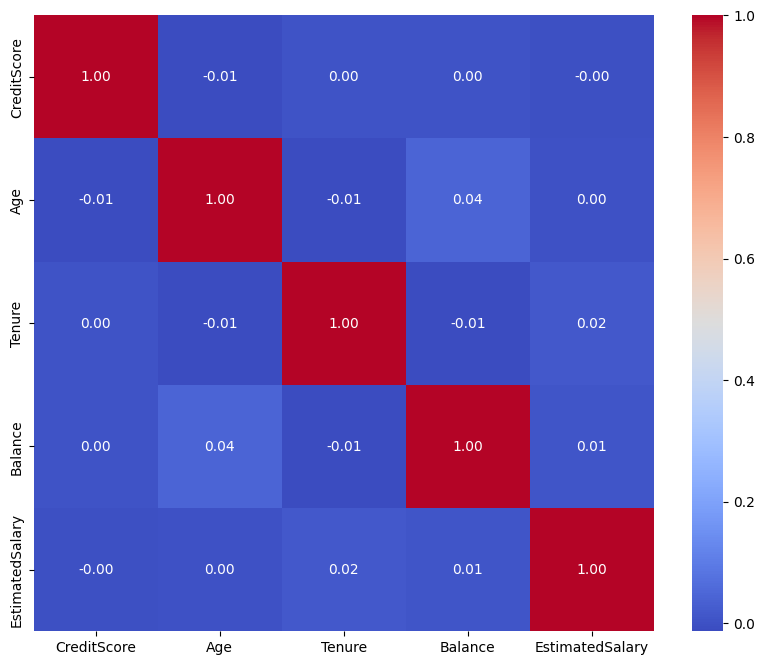

In [3]:
X_num = X_train[['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']]

corr_matrix = X_num.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.show()

Here we found that correlation coefficients are typically low, thus we consider to use all numerical features.

## Saving Data

In [4]:
if not os.path.exists('data/feature_sel'):
    os.makedirs('data/feature_sel')

with open('data/feature_sel/X_train.pkl', 'wb') as file:
    dump(X_train, file)

with open('data/feature_sel/y_train.pkl', 'wb') as file:
    dump(y_train, file)

with open('data/feature_sel/X_test.pkl', 'wb') as file:
    dump(X_test, file)

with open('data/feature_sel/y_test.pkl', 'wb') as file:
    dump(y_test, file)

